In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

from graphufs.stacked_utils import convert_loss_channel2var, get_channel_index
from graphufs.datasets import Dataset

In [2]:
# local variables
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R4"
_prototype_dir_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"
_inference_dir = os.path.join(_scratch, _prototype, _expt,
                              "inference", "validation")

In [3]:
# get the metadata
from prototypes.ocn_only.R4.config import OcnTrainer as Emulator 
em = Emulator()
tds = Dataset(em, mode="training")
xinputs, xtargets, xforcing = tds.get_xarrays(0)
sinputs, stargets = tds[0]

/global/homes/n/nagarwal/graph-ufs/graphufs/fvcoupledemulator.py:25: UserWarning: Could not import flox, install with 'conda install -c conda-forge flox' for faster volume averaging (i.e. groupby operations)
  warnings.warn("Could not import flox, install with 'conda install -c conda-forge flox' for faster volume averaging (i.e. groupby operations)")


In [4]:
# input channels index
tmeta_inp = get_channel_index(xinputs)
tmeta_inp

{0: {'varname': 'LW', 'time': 0},
 1: {'varname': 'SSH', 'time': 0},
 2: {'varname': 'SW', 'time': 0},
 3: {'varname': 'day_progress_cos', 'time': 0},
 4: {'varname': 'day_progress_sin', 'time': 0},
 5: {'varname': 'land_static'},
 6: {'varname': 'landsea_mask', 'z_l': 0},
 7: {'varname': 'landsea_mask', 'z_l': 1},
 8: {'varname': 'landsea_mask', 'z_l': 2},
 9: {'varname': 'landsea_mask', 'z_l': 3},
 10: {'varname': 'landsea_mask', 'z_l': 4},
 11: {'varname': 'landsea_mask', 'z_l': 5},
 12: {'varname': 'landsea_mask', 'z_l': 6},
 13: {'varname': 'so', 'z_l': 0, 'time': 0},
 14: {'varname': 'so', 'z_l': 1, 'time': 0},
 15: {'varname': 'so', 'z_l': 2, 'time': 0},
 16: {'varname': 'so', 'z_l': 3, 'time': 0},
 17: {'varname': 'so', 'z_l': 4, 'time': 0},
 18: {'varname': 'so', 'z_l': 5, 'time': 0},
 19: {'varname': 'so', 'z_l': 6, 'time': 0},
 20: {'varname': 'spfh', 'time': 0, 'level': 0},
 21: {'varname': 'spfh2m', 'time': 0},
 22: {'varname': 'temp', 'z_l': 0, 'time': 0},
 23: {'varname'

In [5]:
tmeta_tar = get_channel_index(xtargets)
tmeta_tar

{0: {'varname': 'SSH', 'time': 0},
 1: {'varname': 'so', 'z_l': 0, 'time': 0},
 2: {'varname': 'so', 'z_l': 1, 'time': 0},
 3: {'varname': 'so', 'z_l': 2, 'time': 0},
 4: {'varname': 'so', 'z_l': 3, 'time': 0},
 5: {'varname': 'so', 'z_l': 4, 'time': 0},
 6: {'varname': 'so', 'z_l': 5, 'time': 0},
 7: {'varname': 'so', 'z_l': 6, 'time': 0},
 8: {'varname': 'temp', 'z_l': 0, 'time': 0},
 9: {'varname': 'temp', 'z_l': 1, 'time': 0},
 10: {'varname': 'temp', 'z_l': 2, 'time': 0},
 11: {'varname': 'temp', 'z_l': 3, 'time': 0},
 12: {'varname': 'temp', 'z_l': 4, 'time': 0},
 13: {'varname': 'temp', 'z_l': 5, 'time': 0},
 14: {'varname': 'temp', 'z_l': 6, 'time': 0},
 15: {'varname': 'uo', 'z_l': 0, 'time': 0},
 16: {'varname': 'uo', 'z_l': 1, 'time': 0},
 17: {'varname': 'uo', 'z_l': 2, 'time': 0},
 18: {'varname': 'uo', 'z_l': 3, 'time': 0},
 19: {'varname': 'uo', 'z_l': 4, 'time': 0},
 20: {'varname': 'uo', 'z_l': 5, 'time': 0},
 21: {'varname': 'uo', 'z_l': 6, 'time': 0},
 22: {'varname'

In [6]:
tmeta_forcing = get_channel_index(xforcing)
tmeta_forcing

{0: {'varname': 'LW', 'time': 0},
 1: {'varname': 'SW', 'time': 0},
 2: {'varname': 'day_progress_cos', 'time': 0},
 3: {'varname': 'day_progress_sin', 'time': 0},
 4: {'varname': 'spfh', 'time': 0, 'level': 0},
 5: {'varname': 'spfh2m', 'time': 0},
 6: {'varname': 'tmp', 'time': 0, 'level': 0},
 7: {'varname': 'ugrd10m', 'time': 0},
 8: {'varname': 'vgrd10m', 'time': 0},
 9: {'varname': 'year_progress_cos', 'time': 0},
 10: {'varname': 'year_progress_sin', 'time': 0}}

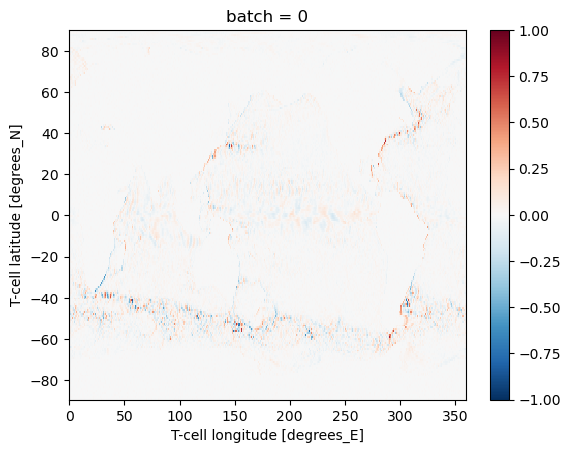

In [26]:
sinputs.isel(batch=0, channels=45).plot(vmin=-1, vmax=1, cmap="RdBu_r")
plt.show()

## Inputs

In [5]:
# open inputs from the training data
ds_dir =  os.path.join(_scratch, _prototype, _expt, "training")
ds = xr.open_zarr(f'{ds_dir}/inputs.zarr/')
ds

<xarray.Dataset> Size: 3TB
Dimensions:   (channels: 118, sample: 37974, lat: 192, lon: 384)
Coordinates:
  * channels  (channels) int64 944B 0 1 2 3 4 5 6 ... 112 113 114 115 116 117
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37969 37970 37971 37972 37973
Data variables:
    inputs    (sample, lat, lon, channels) float64 3TB dask.array<chunksize=(1, 192, 384, 32), meta=np.ndarray>

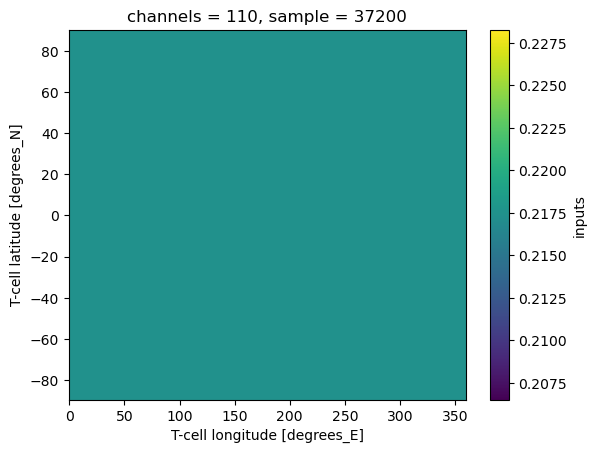

In [13]:
ds.inputs.isel(channels=110, sample=37200).plot()
plt.show()

In [8]:
ds_dir =  os.path.join(_scratch, _prototype, _expt, "stacked-normalization", "inputs")
ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
ds_std = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))

In [11]:
ds_normalized = (ds - ds_mean)/ds_std

In [15]:
computed_mean = ds_normalized.mean(dim=("sample", "lat", "lon")).compute()

In [16]:
computed_std = ds_normalized.std(dim=("sample", "lat", "lon")).compute()

In [21]:
computed_std.inputs.values

array([1.06288801, 1.06288729, 0.8177041 , 0.81770409, 0.86612043,
       0.86611928, 1.00000003, 1.00000003, 0.99999992, 0.99999992,
       0.99999675, 0.99999675, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.00000008, 0.99990298,
       0.99949061, 0.99492457, 0.98988376, 0.98119465, 0.97449091,
       0.96801991, 0.97128378, 0.9682959 , 1.01978434, 1.01968532,
       1.03088639, 1.02617695, 1.02727906, 1.01826174, 1.0089252 ,
       1.00222559, 1.00308566, 1.        , 1.00000007, 1.00030527,
       1.00126869, 1.00748503, 1.0227987 , 1.07993605, 1.18425518,
       1.4023369 , 1.8205492 , 2.34533363, 0.92452589, 0.92480826,
       0.83920241, 0.84441278, 0.72485307, 0.76534619, 0.63994167,
       0.75778747, 0.77624323, 0.99999996, 1.00000482, 1.00000259,
       1.00000401, 1.04832743, 1.0706633 , 1.13862081, 1.15948883,
       1.24459833, 1.23989361, 1.46584929, 1.6892766 , 1.94873

## Targets

In [25]:
# open inputs from the training data
ds_dir =  os.path.join(_scratch, _prototype, _expt, "training")
ds = xr.open_zarr(f'{ds_dir}/targets.zarr/')
ds

<xarray.Dataset> Size: 963GB
Dimensions:   (channels: 43, lat: 192, lon: 384, sample: 37983)
Coordinates:
  * channels  (channels) int64 344B 0 1 2 3 4 5 6 7 ... 35 36 37 38 39 40 41 42
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37978 37979 37980 37981 37982
Data variables:
    targets   (sample, lat, lon, channels) float64 963GB dask.array<chunksize=(1, 192, 384, 32), meta=np.ndarray>

In [26]:
ds_dir =  os.path.join(_scratch, _prototype, _expt, "stacked-normalization", "targets")
ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
ds_std = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))
ds_stddiff = xr.open_zarr(os.path.join(ds_dir, "diffs_stddev_by_level.zarr"))

In [27]:
ds_normalized = (ds - ds_mean)/ds_std

In [28]:
computed_mean = ds_normalized.mean(dim=("sample", "lat", "lon")).compute()

In [ ]:
computed_std = ds_normalized.std(dim=("sample", "lat", "lon")).compute()